**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas

import seaborn
seaborn.set_context('talk')

from sqlalchemy import create_engine, text

In [2]:
import plotly
plotly.__version__


'6.1.1'

In [3]:
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



Comenzamos creando el dataset de datos de airbnb, para luego generar la base de datos en SQLite e ingestar los datos necesarios.

In [4]:
#Datos de airbnb, aplico el promedio por codigo postal
interesting_cols = [
  'zipcode', 'price'
]
airbnb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
    usecols=interesting_cols)

airbnb_df['zipcode'] = pandas.to_numeric(airbnb_df.zipcode, errors='coerce')
airbnb_df['zipcode'] = airbnb_df.zipcode.fillna(0).astype('int')

airbnb_df_filtered = airbnb_df.copy()

relevant_cols = ['price', 'zipcode']
for col in relevant_cols:
    lower = airbnb_df_filtered[col].quantile(0.01)
    upper = airbnb_df_filtered[col].quantile(0.99)


    airbnb_df_filtered = airbnb_df_filtered[(airbnb_df_filtered[col] >= lower) & (airbnb_df_filtered[col] <= upper)]

## Option 1
# Pass a dictionary where the keys are the original columns to aggregate and
# the values are the operations (or list of operations).
airbnb_price_by_zipcode = airbnb_df_filtered[relevant_cols].groupby('zipcode')\
  .agg({'price': ['mean', 'count']})\
  .reset_index()
# Flatten the two level columns
airbnb_price_by_zipcode.columns = [
  ' '.join(col).strip()
  for col in airbnb_price_by_zipcode.columns.values]
# Rename columns
airbnb_price_by_zipcode = airbnb_price_by_zipcode.rename(
    columns={'price mean': 'airbnb_price_mean',
             'price count': 'airbnb_record_count'}
)


/tmp/ipykernel_8250/2528011002.py:5: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_df = pandas.read_csv(


In [5]:
##Formatear datos, rellenar vacios
#Funcion para uniformar los datos de latitud y longitud (está pensada solo para este dataset particular, que solo tiene coordenadas de Melbourne y alrededores, para un dataset distinto no funcionaría correctamente)
def int_with_fixed_integer_digits(value: numpy.float64, int_digits: int) -> numpy.float64:
    s = str(value).replace('.', '')
    if len(s) <= int_digits:
        return float(s)
    integer_part = s[:int_digits]
    decimal_part = s[int_digits:]
    return float(f"{integer_part}.{decimal_part}")

melb_df['Lattitude'] = melb_df['Lattitude'].apply(lambda x: int_with_fixed_integer_digits(x, 3))
melb_df['Longtitude'] = melb_df['Longtitude'].apply(lambda x: int_with_fixed_integer_digits(x, 3))
melb_df['Car'].fillna(0, inplace=True)
melb_df['YearBuilt'].fillna(0, inplace=True)
melb_df['BuildingArea'] = melb_df['BuildingArea'].combine_first(melb_df['Landsize']) #hay varios buildingsarea faltantes, asi que defaulteamos al landsize
melb_df['CouncilArea'].fillna("Unreported", inplace=True)


/tmp/ipykernel_8250/2127368128.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  melb_df['Car'].fillna(0, inplace=True)
/tmp/ipykernel_8250/2127368128.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [6]:
#Genero la base e ingesto ambos dataframes
engine = create_engine('sqlite:///sysarmy.sqlite3', echo=True)

melb_df.to_sql('properties', con=engine, if_exists="replace")
airbnb_price_by_zipcode.to_sql('price_by_zipcode', con=engine, if_exists="replace")

2025-09-09 11:43:33,048 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:33,059 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("properties")
2025-09-09 11:43:33,060 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:33,062 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("properties")
2025-09-09 11:43:33,063 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:33,065 INFO sqlalchemy.engine.Engine SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite~_%' ESCAPE '~' ORDER BY name
2025-09-09 11:43:33,066 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:33,068 INFO sqlalchemy.engine.Engine SELECT name FROM sqlite_master WHERE type='view' AND name NOT LIKE 'sqlite~_%' ESCAPE '~' ORDER BY name
2025-09-09 11:43:33,069 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:33,072 INFO sqlalchemy.engine.Engine PRAGMA main.table_xinfo("properties")
2025-09-09 11:43:33,073 INFO sqlalchemy.engine.Engine [raw sql] ()
202

214

Creamos las consultas de las que queremos obtener respuesta.

In [7]:
#Total de propiedades por ciudad
query1 = "SELECT councilarea, count(1) as total_properties FROM properties group by councilarea"
#Total de propiedades por ciudad/barrio
query2 = "SELECT councilarea, suburb, count(1) as total_properties FROM properties group by councilarea, suburb"
#Total de propiedades por ciudad con mas de 2 habitaciones
query3 = "SELECT councilarea, count(1) as total_properties FROM properties WHERE rooms > 2 group by councilarea"
#Precio promedio de propiedades por ciudad y tipo
query4 = "SELECT councilarea, type, avg(price) as mean_price FROM properties group by councilarea, type"
#Top 5 ciudades con propiedades mas caras
query5 = "SELECT suburb, avg(price) as mean_price FROM properties group by suburb order by mean_price DESC LIMIT 5"
#Join de propiedades con los precios promedios de Airbnb para sus respectivos códigos postales
query6 = "SELECT * FROM properties JOIN price_by_zipcode ON properties.postcode = price_by_zipcode.zipcode limit 10"

queries = [query1, query2, query3, query4, query5, query6]

In [8]:
# Ejecutamos las preguntas
for i, q in enumerate(queries, start=1):
    print(f"Consulta {i}:")
    df_result = pandas.read_sql_query(q, con=engine)
    display(df_result.head())

Consulta 1:
2025-09-09 11:43:35,383 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:35,385 INFO sqlalchemy.engine.Engine SELECT councilarea, count(1) as total_properties FROM properties group by councilarea
2025-09-09 11:43:35,387 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:35,398 INFO sqlalchemy.engine.Engine ROLLBACK


,CouncilArea,total_properties
0,Banyule,594
1,Bayside,489
2,Boroondara,1160
3,Brimbank,424
4,Cardinia,8


Consulta 2:
2025-09-09 11:43:35,405 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:35,406 INFO sqlalchemy.engine.Engine SELECT councilarea, suburb, count(1) as total_properties FROM properties group by councilarea, suburb
2025-09-09 11:43:35,407 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:35,425 INFO sqlalchemy.engine.Engine ROLLBACK


,CouncilArea,Suburb,total_properties
0,Banyule,Bellfield,15
1,Banyule,Briar Hill,5
2,Banyule,Bundoora,13
3,Banyule,Eaglemont,22
4,Banyule,Eltham North,2


Consulta 3:
2025-09-09 11:43:35,436 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:35,437 INFO sqlalchemy.engine.Engine SELECT councilarea, count(1) as total_properties FROM properties WHERE rooms > 2 group by councilarea
2025-09-09 11:43:35,438 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:35,445 INFO sqlalchemy.engine.Engine ROLLBACK


...

,CouncilArea,Type,mean_price
0,Banyule,h,1.029602e+06
1,Banyule,t,7.396453e+05
2,Banyule,u,5.913793e+05
3,Bayside,h,1.986763e+06
4,Bayside,t,1.465254e+06


Consulta 5:
2025-09-09 11:43:35,476 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:35,478 INFO sqlalchemy.engine.Engine SELECT suburb, avg(price) as mean_price FROM properties group by suburb order by mean_price DESC LIMIT 5
2025-09-09 11:43:35,479 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:35,493 INFO sqlalchemy.engine.Engine ROLLBACK


,Suburb,mean_price
0,Kooyong,2.185000e+06
1,Canterbury,2.180241e+06
2,Middle Park,2.082529e+06
3,Albert Park,1.941355e+06
4,Brighton,1.930158e+06


Consulta 6:
2025-09-09 11:43:35,502 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-09 11:43:35,503 INFO sqlalchemy.engine.Engine SELECT * FROM properties JOIN price_by_zipcode ON properties.postcode = price_by_zipcode.zipcode limit 10
2025-09-09 11:43:35,504 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-09 11:43:35,511 INFO sqlalchemy.engine.Engine ROLLBACK


,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,index,zipcode,airbnb_price_mean,airbnb_record_count
0,0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,0.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,54,3067,127.63035,257
1,1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,54,3067,127.63035,257
2,2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,54,3067,127.63035,257
3,3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,0.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,54,3067,127.63035,257
4,4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,54,3067,127.63035,257


## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad? [link text](https://)

## Ejercicio 2.1)

#Columnas a tomar en cuenta

Suburb: Tiene sentido dado que cada barrio va a compartir indicadores socioeconómicos entre si, por lo que a caracteristicas similares, 2 barrios distintos pueden tener distintos precios

Type: El tipo de casa es importante al determinar el precio del mismo, asumimos que el mismo tipo de casa va a tener apreciaciones similares dada igualdad en las otras características.

Rooms: Podemos asumir que las casas de igual cantidad de habitaciones van a tener precios similares

Distance: La distancia al centro de una ciudad es un buen predictor del precio, podemos asumir que a iguales caracteristicas, mas cerca del centro va a ser mas apreciado.

Car: A iguales características, podemos asumir que tener garage va a ser mas apreciado que no tenerlo.

Landsize-BuildingArea: Tanto el terreno como los metros cuadrados totales de una propiedad son importantes a la hora de determinar su precio, son un buen predictor

Yearbuilt: Una casa mas nueva va a tender a ser mas cara que una mas vieja, podemos asumir que dadas caracteristicas similares, el precio va a ser determinante.

Longtitude/Lattitude: Incluso dentro de un mismo barrio, a veces hay zonas mas "lindas" que otras, además de que es la mejor variable para determinar la ubicación de una propiedad

#Columnas desestimadas:
Postcode: Lo obviamos por incluir suburb, latitud y longitud (sin embargo, lo incluimos igual para poder joinear con los datos del dataset de airbnb)

Address: Lo obviamos por incluir suburb, y es complicado de usar sin convertirlo antes en algo mas parecido a coordenadas geográficas.

Bedroom2: Superfluo teniendo rooms

CouncilArea: Superfluo teniendo variables de localización mas precisas

RegionName: Superfluo teniendo variables de localización mas precisas

PropertyCount: Superfluo porque es un dato que deriva de Suburb

Date: No hay tanta variación en la fecha de recabado de los datos, por lo que podemos obviarla

In [9]:
# Empezamos viendo las columnas relevantes
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [10]:
rel_cols = ['Suburb', 'Rooms', 'Type', 'Distance', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Longtitude', 'Lattitude', 'Postcode']

In [11]:
# Veamos el porcentaje de filas con al menos un valor faltante
missing_rows = melb_df[rel_cols].isnull().any(axis=1).mean() * 100
print(f"Porcentaje de filas con al menos un valor faltante: {missing_rows:.2f}%")

Porcentaje de filas con al menos un valor faltante: 49.71%


El porcentaje de filas con al menos un dato faltante es muy alto. Veamos de donde viene ese problema.

In [12]:
melb_df[rel_cols].isnull().sum()

Suburb             0
Rooms              0
Type               0
Distance           0
Car               62
Landsize           0
BuildingArea    6450
YearBuilt       5375
Longtitude         0
Lattitude          0
Postcode           0
dtype: int64

Podemos ver que casi todos los datos faltantes vienen de las columnas 'YearBuilt' y 'BuildingArea' por lo que decidimos no tenerlas en cuenta para así no despreciar una gran cantidad de datos.

In [13]:
melb_df['Landsize_or_BuildingArea'] = melb_df.apply(
    lambda row: row['Landsize'] if (row['Landsize'] > 0)
                else (row['BuildingArea'] if (pandas.notnull(row['BuildingArea']))
                      else row['Landsize']),
    axis=1
)

rel_cols.remove('YearBuilt')
rel_cols.remove('BuildingArea')
rel_cols.remove('Landsize')
rel_cols.append('Landsize_or_BuildingArea')

In [14]:
# Veamos el porcentaje de filas con al menos un valor faltante ahora
missing_rows = melb_df[rel_cols].isnull().any(axis=1).mean() * 100
print(f"Porcentaje de filas con al menos un valor faltante: {missing_rows:.2f}%")

Porcentaje de filas con al menos un valor faltante: 0.46%


In [15]:
#Llenamos Car con 0, para no tener los NaN
melb_df['Car'].fillna(0, inplace=True)


/tmp/ipykernel_8250/3794427368.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  melb_df['Car'].fillna(0, inplace=True)


Ahora veamos la distribución de las columnas numéricas relevantes.

In [16]:
numeric_cols = ['Rooms', 'Distance', 'Car', 'Landsize_or_BuildingArea', 'Longtitude', 'Lattitude', 'Postcode']


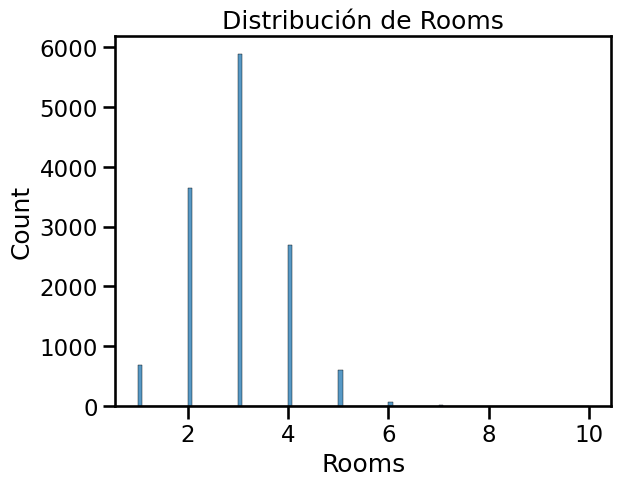

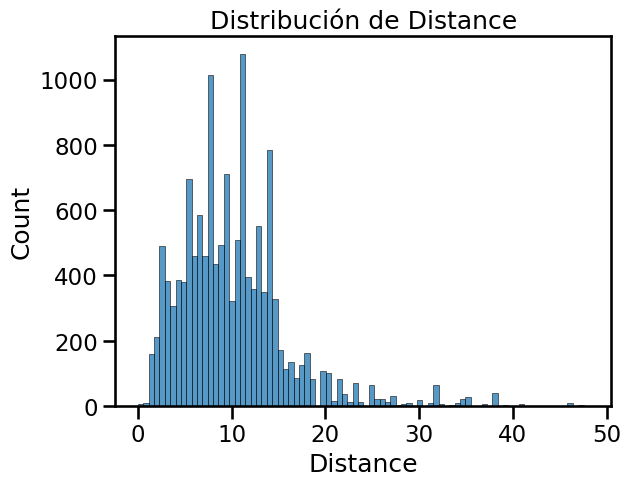

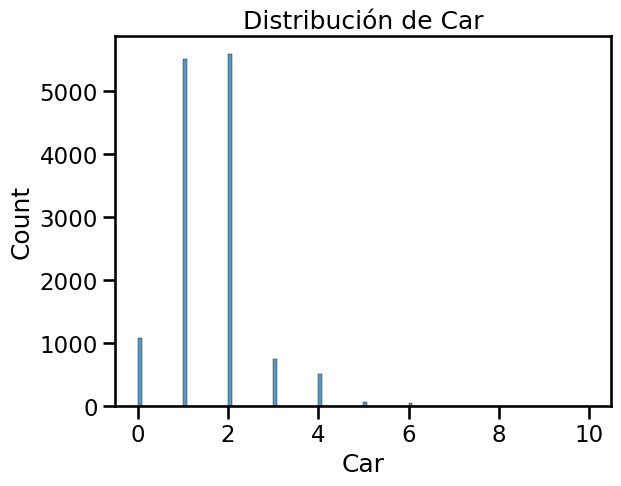

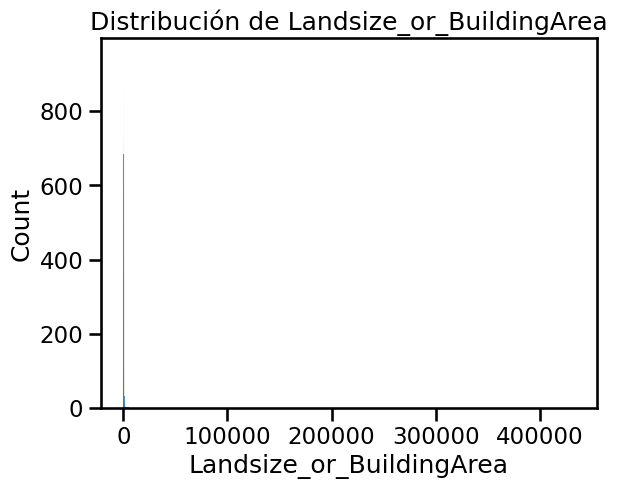

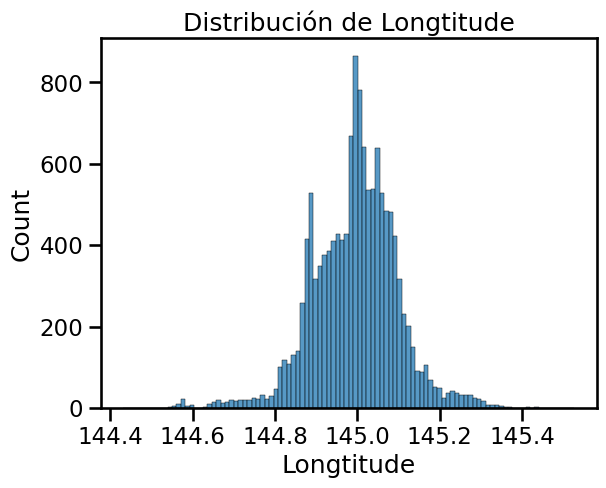

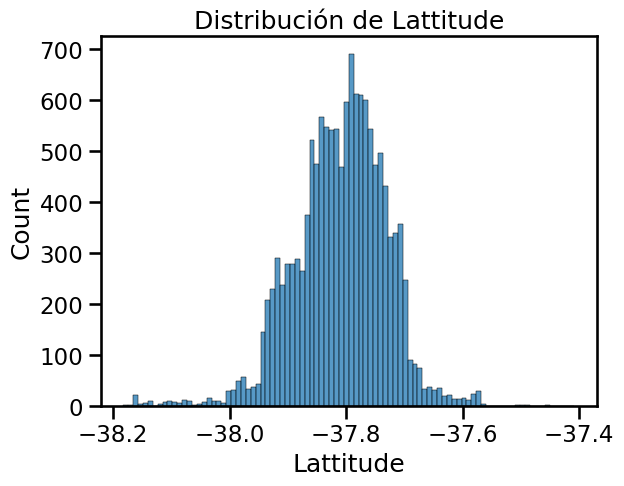

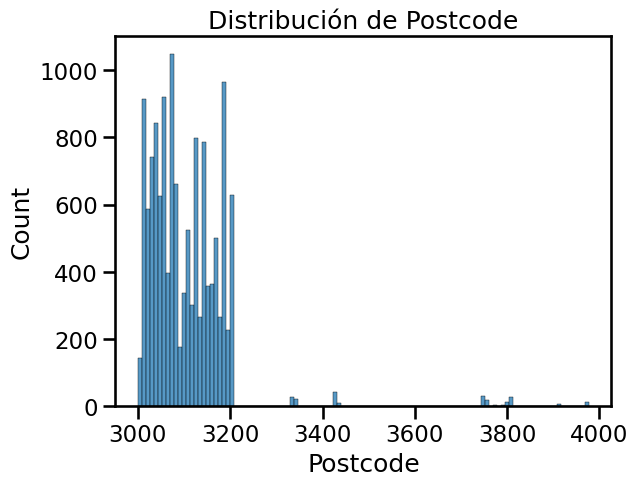

In [17]:
# Veamos la distribución de las columnas numéricas relevantes
for col in numeric_cols:
    seaborn.histplot(melb_df[col].dropna())
    plt.title(f'Distribución de {col}')
    plt.show()

Eliminamos los datos extremos teniendo en cuenta el percentil 1 y el percentil 99. Además, guardamos los outliers para luego graficarlos.

In [18]:
# Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
# Podemos eliminar los datos por encima del percentil 99 y debajo del percentil 1

melb_df_filtered = melb_df.copy()

# Para el landsize sacamos el valor 0 también
melb_df_filtered = melb_df_filtered[melb_df_filtered['Landsize'] > 0]

# Lista para guardar outliers de todas las columnas
outliers_dfs = []

#Excluimos el codigo postal de las columnas porque ambos extremos son codigos postales válidos que pertenecen al área metropolitana de Melbourne
columns_to_filter = [column for column in numeric_cols if column != 'Postcode']

for col in columns_to_filter:
    lower = melb_df_filtered[col].quantile(0.01)
    upper = melb_df_filtered[col].quantile(0.99)

    # Datos outliers para esa columna (comparado con el df sin filtrar)
    #outliers = melb_df_filtered[(melb_df_filtered[col] < lower) | (melb_df_filtered[col] > upper)]
    #outliers_dfs.append(outliers)
    outliers = melb_df[(melb_df[col] < lower) | (melb_df[col] > upper)]
    outliers_dfs.append(outliers)


    # Acumulo filtrado para la siguiente iteración
    melb_df_filtered = melb_df_filtered[(melb_df_filtered[col] >= lower) & (melb_df_filtered[col] <= upper)]

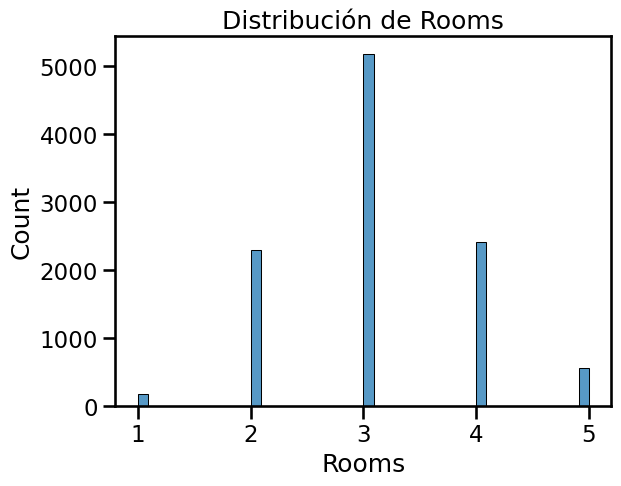

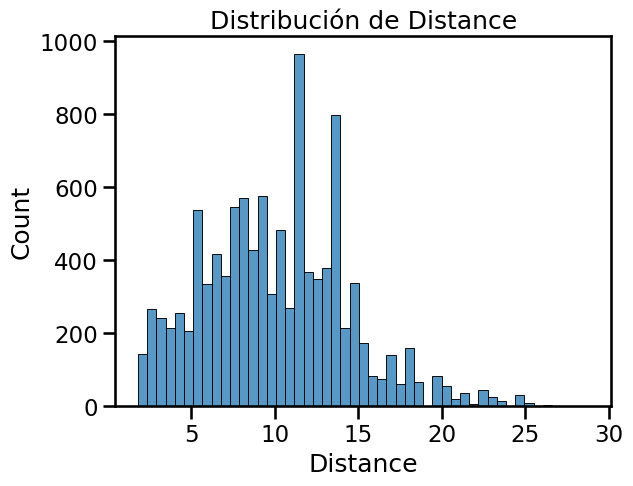

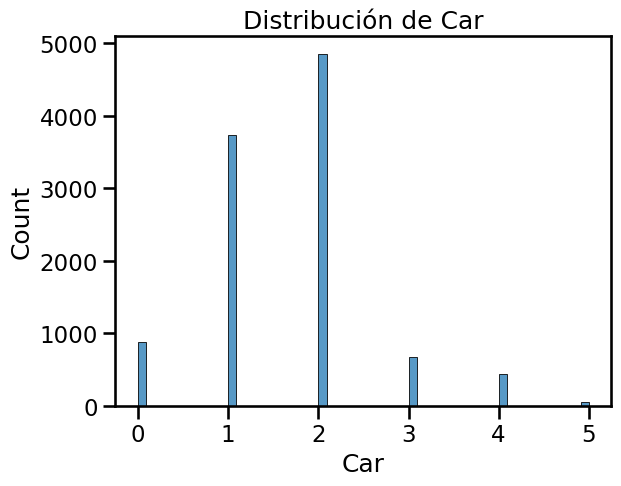

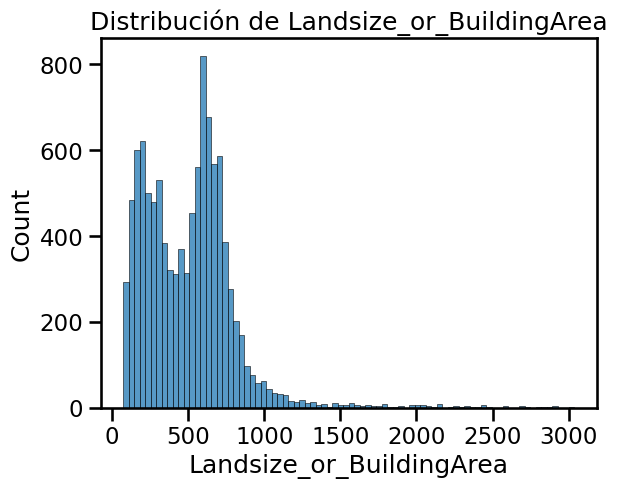

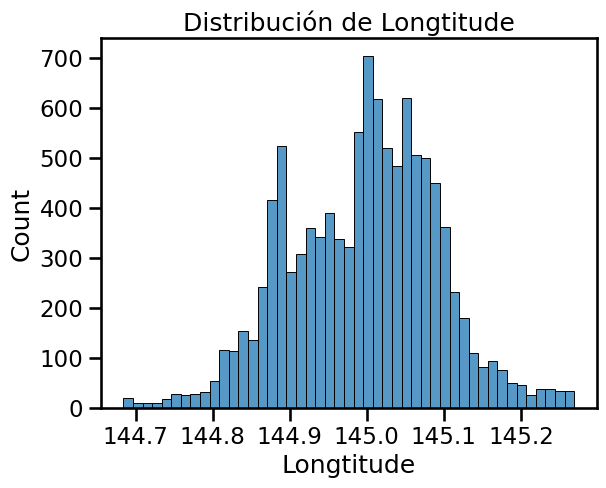

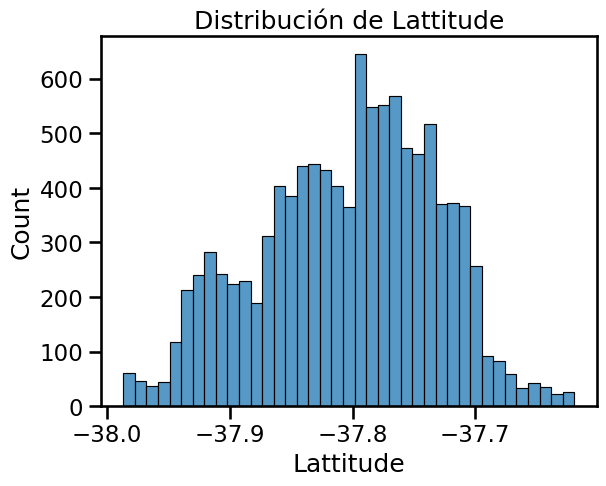

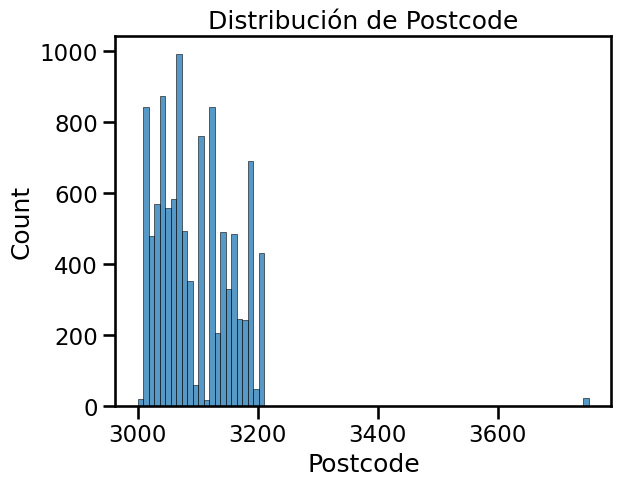

In [19]:
# Veamos la nueva distribución de las columnas numéricas relevantes
for col in numeric_cols:
    seaborn.histplot(melb_df_filtered[col].dropna())
    plt.title(f'Distribución de {col}')
    plt.show()

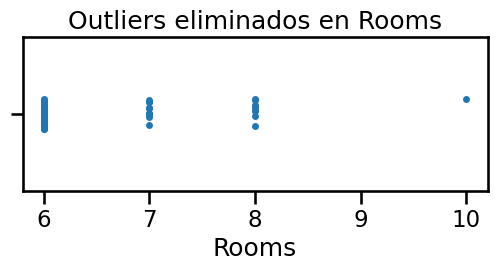

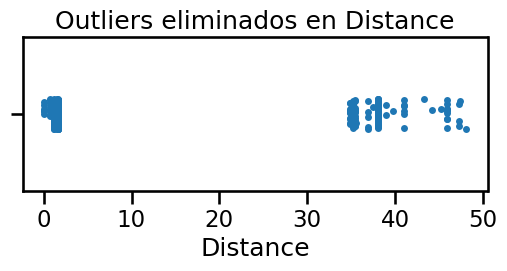

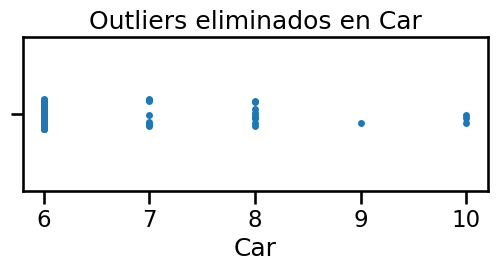

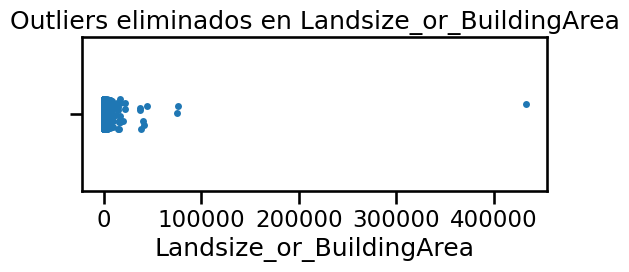

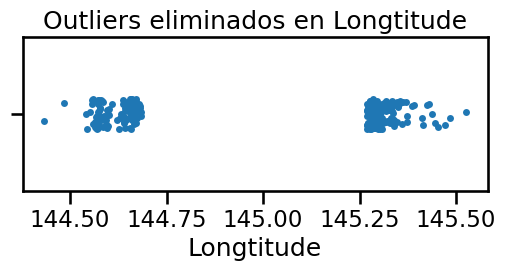

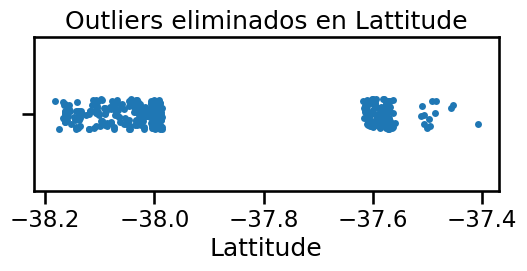

In [20]:
# Graficamos los valores extremos eliminados
for col, outliers in zip(numeric_cols, outliers_dfs):
    plt.figure(figsize=(6,2))
    seaborn.stripplot(x=outliers[col], jitter=True)
    plt.title(f'Outliers eliminados en {col}')
    plt.show()

## Ejercicio 2.2)

Agreguemos información a partir del conjunto de datos de AirBnB.

In [21]:
airbnb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
    )
airbnb_df.head()

/tmp/ipykernel_8250/2356907632.py:1: DtypeWarning: Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_df = pandas.read_csv(


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,neighborhood_overview,notes,...,review_scores_location,review_scores_value,requires_license,license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,9835,https://www.airbnb.com/rooms/9835,2.018120e+13,12/7/2018,Beautiful Room & House,NaN,"House: Clean, New, Modern, Quite, Safe. 10Km f...","House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,NaN,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,1,0.04
1,10803,https://www.airbnb.com/rooms/10803,2.018120e+13,12/7/2018,Room in Cool Deco Apartment in Brunswick,A large air conditioned room with queen spring...,The apartment is Deco/Edwardian in style and h...,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,NaN,...,9.0,9.0,f,NaN,t,moderate,t,t,1,1.50
2,12936,https://www.airbnb.com/rooms/12936,2.018120e+13,12/7/2018,St Kilda 1BR APT+BEACHSIDE+VIEWS+PARKING+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,FREE WiFi FREE in-building remote controlled g...,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,First floor apartment with both lift and stair...,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,17,0.15
3,15246,https://www.airbnb.com/rooms/15246,2.018120e+13,12/7/2018,Large private room-close to city,"Comfortable, relaxed house, a home away from ...",The atmosphere is relaxed and easy going. You ...,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...",A simple self service breakfast is available –...,...,9.0,9.0,f,NaN,f,moderate,f,f,3,0.30
4,16760,https://www.airbnb.com/rooms/16760,2.018120e+13,12/7/2018,Melbourne BnB near City & Sports,NaN,We offer comfortable accommodation in Inner Me...,We offer comfortable accommodation in Inner Me...,NaN,NaN,...,10.0,9.0,f,NaN,f,moderate,f,f,1,0.74


Podemos agregar todas las variables correspondientes al precio, tanto del día como semanal y mensual.

A la columna `price` le podemos aplicar la mediana que es una medida más robusta frente a outliers que la media y el mínimo para poder visualizar las zonas donde hay precios más bajos. Además, agregamos el `count` para ver la cantidad de registros. Para el `weekly_price` y `monthly_price`, basta con ver la mediana.

Por otro lado, también puede ser útil tener información sobre la accesibildad anual media (aplicarle `mean` a `availability_365`) y la puntuación media (aplicarle `mean` a `review_scores_rating`). Esto nos da tanto una medida sobre que zonas tienen más disponibilidad durante el año y cuales son las más valoradas por los usuarios.

In [22]:
# Hacemos que zipcode sea float
airbnb_df['zipcode'] = pandas.to_numeric(airbnb_df.zipcode, errors='coerce')
# Agregamos las variables correspondientes al precio
relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode', 'availability_365', 'review_scores_rating']

# Agrupamos por zipcode y aplicamos las operaciones
airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
  .agg({'price': ['median', 'min', 'count'], 'weekly_price': 'median',
        'monthly_price': 'median', 'availability_365':'mean', 'review_scores_rating':'mean'})\
  .reset_index()
# Hacemos un flatten
airbnb_price_by_zipcode.columns = [
  ' '.join(col).strip()
  for col in airbnb_price_by_zipcode.columns.values]
# Renombramos las columnas
airbnb_price_by_zipcode = airbnb_price_by_zipcode.rename(
    columns={'price median': 'airbnb_price_median',
             'price min': 'airbnb_record_min',
             'price count': 'airbnb_price_count',
             'weekly_price median': 'airbnb_weekly_price_median',
             'monthly_price median': 'airbnb_monthly_price_median',
             'availability_365 mean': 'airbnb_availability_365_mean',
             'review_scores_rating mean': 'airbnb_review_scores_rating_mean'}
)


airbnb_price_by_zipcode[:5]

,zipcode,airbnb_price_median,airbnb_record_min,airbnb_price_count,airbnb_weekly_price_median,airbnb_monthly_price_median,airbnb_availability_365_mean,airbnb_review_scores_rating_mean
0,2010.0,40.0,40,1,NaN,NaN,0.000000,NaN
1,2134.0,50.0,50,1,NaN,NaN,88.000000,NaN
2,2582.0,104.0,104,1,NaN,NaN,365.000000,NaN
3,3000.0,129.0,0,3367,857.0,3469.0,125.234333,92.775407
4,3001.0,132.5,120,2,NaN,NaN,94.500000,86.500000


Ahora utilicemos la variable `zipcode` para unir los conjuntos de datos. Vamos a unir todos los que tengan al menos 10 registros.

In [23]:
# Filtramos por los zipcode que tengan más de 10 registros
airbnb_price_by_zipcode_filtered = airbnb_price_by_zipcode[
    airbnb_price_by_zipcode['airbnb_price_count'] > 10
]

# Hacemos el merge
merged_sales_df = melb_df_filtered.merge(
    airbnb_price_by_zipcode_filtered, how='left',
    left_on='Postcode', right_on='zipcode'
)
merged_sales_df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Propertycount,Landsize_or_BuildingArea,zipcode,airbnb_price_median,airbnb_record_min,airbnb_price_count,airbnb_weekly_price_median,airbnb_monthly_price_median,airbnb_availability_365_mean,airbnb_review_scores_rating_mean
6877,Fairfield,60 Station St,3,h,1550000.0,S,Jellis,1/07/2017,5.7,3078.0,...,2970.0,478.0,3078.0,79.0,19.0,74.0,395.0,1850.0,155.567568,93.406780
7237,Preston,26A Young St,3,h,955000.0,S,Nelson,3/06/2017,8.4,3072.0,...,14577.0,263.0,3072.0,71.0,12.0,141.0,450.0,1300.0,117.028369,95.489796
9001,Aberfeldie,5 Aroona Ct,3,h,1680000.0,SP,Raine,22/07/2017,7.5,3040.0,...,1543.0,673.0,3040.0,82.0,19.0,56.0,775.0,4000.0,126.732143,92.744186
4452,South Yarra,12/2 Gordon Gr,2,u,635000.0,S,Beller,25/02/2017,3.3,3141.0,...,14887.0,855.0,3141.0,120.0,0.0,881.0,836.0,3030.0,130.850170,94.469630
9546,Fairfield,103 Arthur St,3,h,1492000.0,S,Nelson,3/09/2017,5.7,3078.0,...,2970.0,292.0,3078.0,79.0,19.0,74.0,395.0,1850.0,155.567568,93.406780


Ahora, hagamos un gráfico del zipcode vs. la mediana del precio.

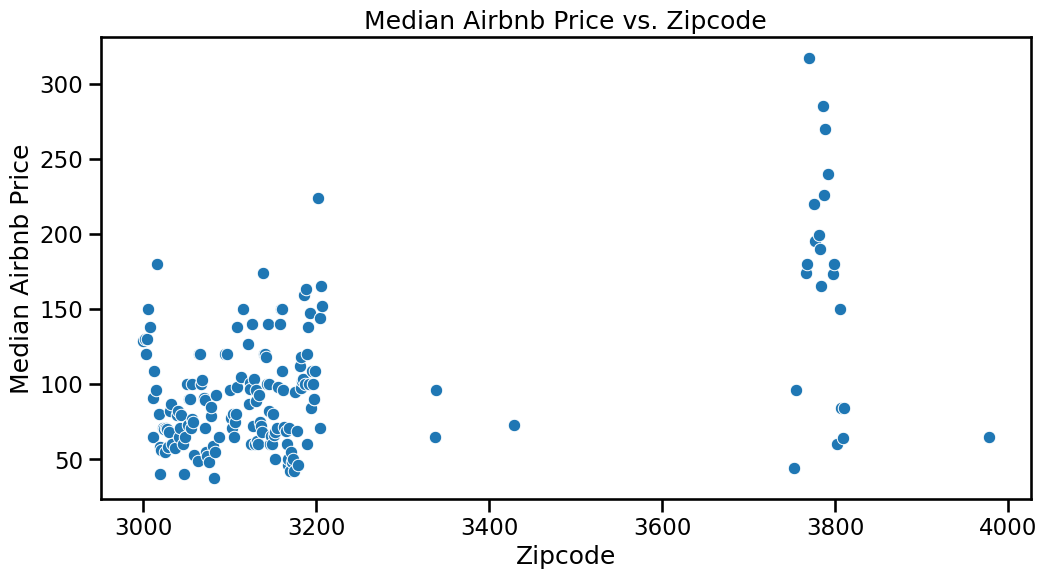

In [24]:
plt.figure(figsize=(12, 6))
seaborn.scatterplot(data=airbnb_price_by_zipcode_filtered, x='zipcode', y='airbnb_price_median')
plt.title('Median Airbnb Price vs. Zipcode')
plt.xlabel('Zipcode')
plt.ylabel('Median Airbnb Price')
plt.show()

## Ejercicio 2.2.4



Otras variables que creemos son adecuadas y pueden combinarse son rooms de melb_df y la suma de bathrooms y bedrooms de airbnb_df.  

También, asumiendo que tuviéramos acceso a buenos anotadores y capacidad de usar las coordenadas geoespaciales (técnicamente aparecen en ambos datasets, pero no es trivial su uso) se podría hacer mejores predicciones en de precio en base a la ubicación geográfica (las coordenadas son mucho mas exactas que los otros valores disponibles, y suele ocurrir que se generan "zonas" más granulares que un barrio, por ejemplo (Ejemplo, zonas próximas a una boca de subte)).

Otra opción que se nos ocurrió, es utilizar las columnas del dataset de airbnb `neighbourhood_overview` y `transit` para obtener información referente a las características del barrio y las opciones de transporte disponibles, probablemente mediante análisis de sentimiento o palabras clave como tags.



Como datos que no aparecen y podrían ser útiles para predecir precios, se podría tener datos sobre crímenes por zona, accidentes de tránsito, proximidad a fábricas/focos de contaminación, indicadores de polución, cercanía a la costa, cercanía a establecimientos educativos.

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

In [25]:
merged_sales_df.to_csv("merged_sales_with_airbnb_data.csv", index=None)

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)